# 4: Causal Discovery

Traditional causal inference requires a pre-built causal model, often impractical to construct.
Causal discovery instead uses observational data to find causal links.

This chapter introduces computational techniques for causal discovery, outlining the assumptions underlying different algorithms.
It analyses their strengths and weaknesses before applying them to a real-world case study, demonstrating practical utility.

## 4.1: Assumptions of Causal Discovery

In modelling, a **forward problem** predicts outcomes from given inputs (e.g., estimating causal effects from a model).
An **inverse problem** identifies inputs from observed outcomes (e.g., discovering a causal model from data).
Solving inverse problems is harder, as multiple models may fit the same data (Maclaren & Nicholson, 2019).

Solving inverse problems typically requires assumptions to narrow solutions.
Four common assumptions are used in causal discovery algorithms (Verma & Pearl 2022; Frydenberg 1990).


### 4.1.1: Markov Assumption

The **Markov assumption** states that in causal graphs, each node is conditionally independent of its non-descendants given its parents.
Knowing a node's parents makes other variables irrelevant for predicting it, simplifying complex causal structures into conditional independence statements.

> 💡 Tip
>
> Under the Markov assumption, d-separated variables in graph G are independent in distribution P.

$$X \perp_G Y | Z \implies X \perp_P Y | Z$$


### 4.1.2: Faithfulness Assumptions

**Faithfulness** is the opposite of the Markov assumption: statistical independencies in $P$ imply d-separations in $G$.

$$X \perp_G Y | Z \impliedby X \perp_P Y | Z$$

Violations of the faithfulness assumption occur when observed statistical dependencies do not match d-separations in a causal graph.
For example, if two causal paths between nodes cancel each other, the nodes may appear statistically independent in the data despite not being d-separated.


### 4.1.3: Causal Sufficiency

**Causal sufficiency** assumes all relevant variables are measured, with no unmeasured confounders affecting both exposure and outcome.


### 4.1.4: Acyclicity

The **acyclicity assumption** in causal discovery requires no directed cycles (feedback loops) in the causal graph.


## 4.2: From Assumptions to Structures

**Markov equivalence** identifies graphs with identical conditional independencies, reducing structural search in causal models.

> 💡 Tip
>
> Two graphs are **Markov equivalent** if they share the same conditional independencies, enabling simplification of causal models.

**Chains** and **forks** (Chapter 3) share a Markov equivalence class, distinct from the immorality structure.
Under Markov assumptions, all chains and forks share a standard skeleton: the graph's undirected version.

Two key graph properties for distinguishing structures are immoralities and the skeleton, underpinning a key theorem.

_Two graphs are Markov equivalent if they share the same skeleton and immoralities._

We discover partially directed graphs from data by analysing conditional dependencies to build a skeleton and direct edges using immoralities.


## 4.3: Causal Discovery Algorithms

This section examines how causal discovery algorithms find causal links in observational or experimental data.


### 4.3.1: Constraint-Based Algorithms

Constraint-based causal discovery uses conditional independence tests, which can be difficult when variable dependence is unclear.
While applicable across many domains, effectiveness depends on large sample sizes for accurate tests.
A key drawback is reliance on the faithfulness assumption, which is often hard to satisfy in practice.


#### 4.3.1.1: PC Algorithm

The **PC algorithm** (Spirtes et al. 2000) is an early causal discovery method relying on the causal Markov condition, faithfulness, and no latent confounders.

> PC may stand for Partial Correlation (concept used in the algorithm) but actually references the initial letters of the names of the two main authors (Peter Spirtes and ClarkGlymour).

Consider an example with a known causal structure.
The PC algorithm reconstructs this structure, as shown in [Figure 4.1](#fig-pc).

<center>
  <img
    src="images/pc_algorithm_steps.png"
    alt="PC algorithms and steps"
    width="400"/>
  <a id="fig-pc"></a>
  <h6>Figure 4.1: PC algorithms and steps</h6>
</center>

The steps of the PC algorithm are:

1. Create a complete undirected, fully connected graph on all the variables.
2. Remove all the independent edges from the observational data.
   For example, remove the edge $X \longleftrightarrow Y$ because $X \perp Y$.
3. Remove any edge $X \longleftrightarrow Y$ if $A$ and $B$ are conditionally independent given some $C$ connected to $A$ or $b$.
  For example, remove the edges $X \longleftrightarrow W$ and $Y \longleftrightarrow W$ since $X \perp W|_Y$ and $Y \perp W|_Z$.
4. A v-structure occurs when $A \longleftrightarrow B$, $A \longleftrightarrow C$, and not $A \longleftrightarrow C$.
   Provided that $B$ wasn't part of the conditioning set that made $A$ and $C$ independent, replace the edges in the v-structure with $A \longrightarrow B \longleftarrow C$.
   For example, removing $X \longleftrightarrow Y$ that has no conditioning on $Z$ leaves behind a v-structure that can be replaced with $X \longrightarrow Z \longleftarrow Y$.
5. Set $B \longrightarrow C$ in a triple $A \longrightarrow B \longleftrightarrow C$ if $A$ and $C$ are non-adjacent.
   For example, orienting $Y \longrightarrow Z \longleftrightarrow W$ as $Y \longrightarrow Z \longrightarrow W$ uniquely recovers the structure.

> 💡 Tip
>
> The PC algorithm converges to the true Markov equivalence class with large samples if conditional independence decisions are accurate.


#### 4.3.1.2 FCI Algorithm

*Fast Causal Inference (FCI)* is a constraint-based algorithm capable of identifying unknown confounders that is more efficient and scalable than the PC algorithm (Spirtes et al., 2000).

FCI and PC algorithms are similar: both start with a fully connected undirected graph and remove edges between conditionally independent variables.

The algorithm first removes edges based on conditional independence.
It then orients the remaining edges where possible, typically using collider structures (e.g., $X \longrightarrow Y \longleftarrow Z$ when $X$ and $Z$ are unconditionally independent).
Undirected edges (marked by circles at nodes) indicate unknown directionality, signifying unobserved confounding or indeterminate relationships between variables.

<center>
  <img
    src="images/fci.png"
    alt="FCI Algorithm"
    width="400"/>
  <a id="fig-fci"></a>
  <h6>Figure 4.2: FCI Algorithm</h6>
</center>

Spirtes et al. introduced Anytime FCI (AFCI, 2001), a variant of FCI that uses smaller conditioning sets than a fixed $K$ threshold.

*Really Fast Causal Inference (RFCI)* is faster than FCI as it uses fewer conditional independence tests on smaller variable subsets.
It is more reliable with small samples, avoiding power issues in high-order tests.
However, this reduces result informativeness.

Current Causal Discovery (CCD) and SAT-based methods remove acyclicity and causal sufficiency assumptions (Richardson 1996; Hyttinen et al. 2013).


### 4.3.2 Score-Based Algorithms

Score-based algorithms start with an undirected graph and iteratively adjust edges to maximise a score.
Common scores include **Bayesian Information Criterion (BIC)**, **Akaike Information Criterion (AIC)**, and **Maximum Likelihood (ML)**, which balance model complexity against fit to prevent overfitting and ensure reliable causal inferences.


#### 4.3.2.1 Greedy Equivalence Search Algorithm

The **Greedy Equivalence Search (GES)** is a causal discovery algorithm that builds a partially directed graph from data.
It starts with an empty graph and iteratively adds edges using score functions (like BIC) to maximise fit.
GES uses a greedy approach to select edges improving the score, plus backtracking to correct edge directions.

The **Greedy Fast Causal Inference (GFCI)** algorithm (Ogarrio et al., 2016) combines GES and FCI for causal discovery.
GES generates a supergraph skeleton, which FCI then prunes and orients correctly.

Fast **Greedy Equivalence Search (FGES)** combines GES and FCI, using a parallelised GES variant and v-structures to determine edge directions.


### 4.3.3 Semi-Parametric Algorithms

Causal inference methods face three key limitations:

1. They rely on the faithfulness assumption, which may not hold.
2. They often require large sample sizes for accurate conditional independence testing.
3. They can only identify Markov equivalent causal structures, failing to distinguish between models with identical conditional independence patterns.

Based on Geiger and Pearl (1990) and Meek (2013), multinomial or linear Gaussian models only identify graphs up to Markov equivalence.
However, under **linear non-Gaussian noise** or **nonlinear additive noise settings** (with semi-parametric assumptions), the causal graph becomes fully identifiable.


### 4.3.3.1 Linear Non-Gaussian Noise (LiNGAM)

In linear non-Gaussian noise settings, structural equations take this form:

$$Y := f(X) + U$$

with linear $f(X)$, $X \perp U$, and unobserved non-Gaussian $U$ (Shimizu et al. 2006).

Darmois and Skitovich (1953, 1954) established identifiability in linear non-Gaussian systems.
Specifically, if the true structural causal model is $Y := f(X) + U$ with $X \perp U$, no reverse model $X = f(Y) + \tilde{U}$ with $Y \perp \tilde{U}$ can reproduce the joint distribution $P(X,Y)$.

In non-linear Gaussian models, the causal direction $X \longrightarrow Y$ is identified when residuals are independent of the input.
Conversely, for the anti-causal direction $X \longleftarrow Y$, residuals depend on the input.

Extensions have relaxed key assumptions: Shimizu et al. (multivariate), Hoyer et al. (causal sufficiency), and Lacerda et al. (acyclicity, 2012).


#### 4.3.3.2 Nonlinear Additive Noise

Nonlinear additive noise models identify causal graphs by assuming nonlinear causal mechanisms with additive noise (Hoyer et al., 2008).

$$\forall_i X_i := f(pa_i) + U_i$$

where $f$ is nonlinear and $pa_i$ are $X$'s parents.

Zhang and Hyvarinen (2012) extended the model by replacing nonlinear additive noise with a post-nonlinear transformation applied after noise addition.

$$\forall_i X_i := g(f(pa_i) + U_i) for all i,$$

with X independent of U ($X \perp U$).


## 4.4 Case Study

We'll use Sachs et al. (2005)'s dataset to reconstruct a biological signalling pathway with near-perfect accuracy from flow cytometry data.

The study succeeded due to no known latent confounders affecting variables, and using observations with perturbations to correctly orient edges.

We compare algorithms against true causal graphs to assess their relative strengths.
Code for this case study is available in the [Colab notebook](https://colab.research.google.com/drive/1Vb-GISvjprqYDwSoHxcgfq_Y1hP0c4bM?usp=sharing).


### 4.4.1 Dataset

The study measured 11 phosphorylated proteins and phospholipids using flow cytometry.

- **Raf** (praf): S259
- **Erk1/2** (p44/p42): T202/Y204
- **p38** (p38): T180/Y182
- **Jnk** (pjnk): T183/Y185
- **AKT** (pakts473): S473
- **Mek1/2** (pmek): S217/S221
- **PKA substrates** (pka): Arg at –3
- **PKC** (PKC): C-terminal S660
- **PLC-g** (plcg): Y783
- **PIP2/PIP3** (PIP2/PIP3): Detection

We use the raw data from the [Causal Discovery Toolbox](https://github.com/FenTechSolutions/CausalDiscoveryToolbox/tree/master/cdt/data/resources).


In [1]:
SACHS_DATA = "https://raw.githubusercontent.com/ElementAI/causal_discovery_toolbox/master/cdt/data/resources/cyto_full_data.csv"

### 4.4.2 Tools and Libraries

We used `causal-learn` for causal analysis, `networkx` for graph visualization, `pandas` for correlation, and `numpy` for data handling.


In [2]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### 4.4.3 Analysis

We'll start with basic statistical analysis to identify correlations and data distribution.

We'll apply causal discovery algorithms and analyse results for missing edges, misdirected relationships, and algorithm errors.

We aim to summarise observations using the true causal graph and compare algorithm results to assess method strengths and weaknesses.


In [4]:
data = np.loadtxt(SACHS_DATA, skiprows=1, delimiter=",")

#### 4.4.3.1 Exploratory Data Analysis

[Figure 4.3](#fig-describe) shows 7,466 observations across 11 variables.
Means range from 27.03 (PIP3) to 625.76 (PKA), with standard deviations from 43.05 (PIP3) to 644.46 (PKA).
Percentiles show wide variation, suggesting differing distributions and possible skewness.

In [5]:
# Load your dataset (replace 'your_data.csv' with your actual file)
sachs_df = pd.read_csv(SACHS_DATA)

# Display the summary statistics in a pretty way
summary_stats = sachs_df.describe()
styled_summary_stats = summary_stats.style.format("{:.2f}").set_caption(
    "Summary Statistics"
)
display(styled_summary_stats)

,praf,pmek,plcg,PIP2,PIP3,p44/42,pakts473,PKA,PKC,P38,pjnk
count,7466.00,7466.00,7466.00,7466.00,7466.00,7466.00,7466.00,7466.00,7466.00,7466.00,7466.00
mean,124.07,145.38,54.85,151.12,27.03,26.63,81.17,625.76,30.34,135.01,73.27
std,247.53,377.06,173.86,299.35,43.05,45.83,137.77,644.46,92.87,494.77,215.66
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,30.80,16.50,9.41,18.30,9.56,8.51,23.30,276.00,4.46,19.30,8.01
50%,53.80,26.70,16.50,52.80,17.80,17.20,37.20,449.00,12.70,30.50,18.40
75%,103.00,64.40,27.10,172.00,32.80,32.20,72.30,750.00,23.50,49.60,52.80
max,4614.00,7105.00,6208.00,9058.00,1275.00,2571.00,3555.00,8896.00,1611.00,7499.00,4740.00


<center>
  <a id="fig-describe"></a>
  <h6>Figure 4.3: Basic Statistics for the Cytometry Dataset</h6>
</center>

[Figure 4.4](#fig-scatter) shows correlations requiring causal analysis, such as between pmek and praf, plcg and PIP2, and PKC and p38.

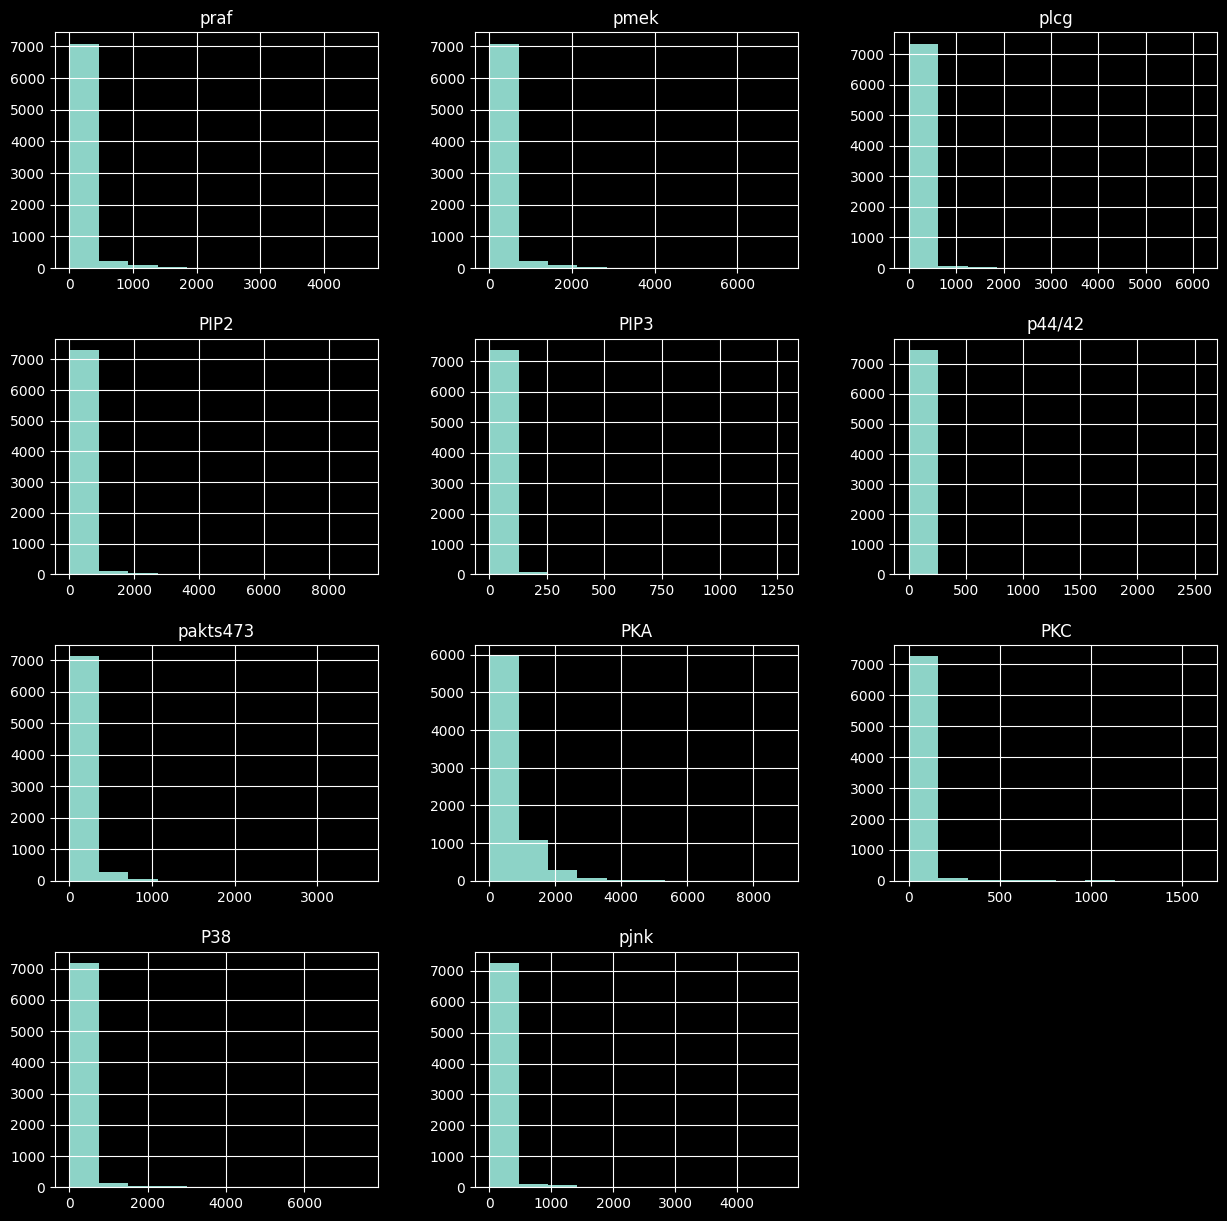

In [6]:
# Plot histograms for each variable
sachs_df.hist(figsize=(15, 15))
plt.show()

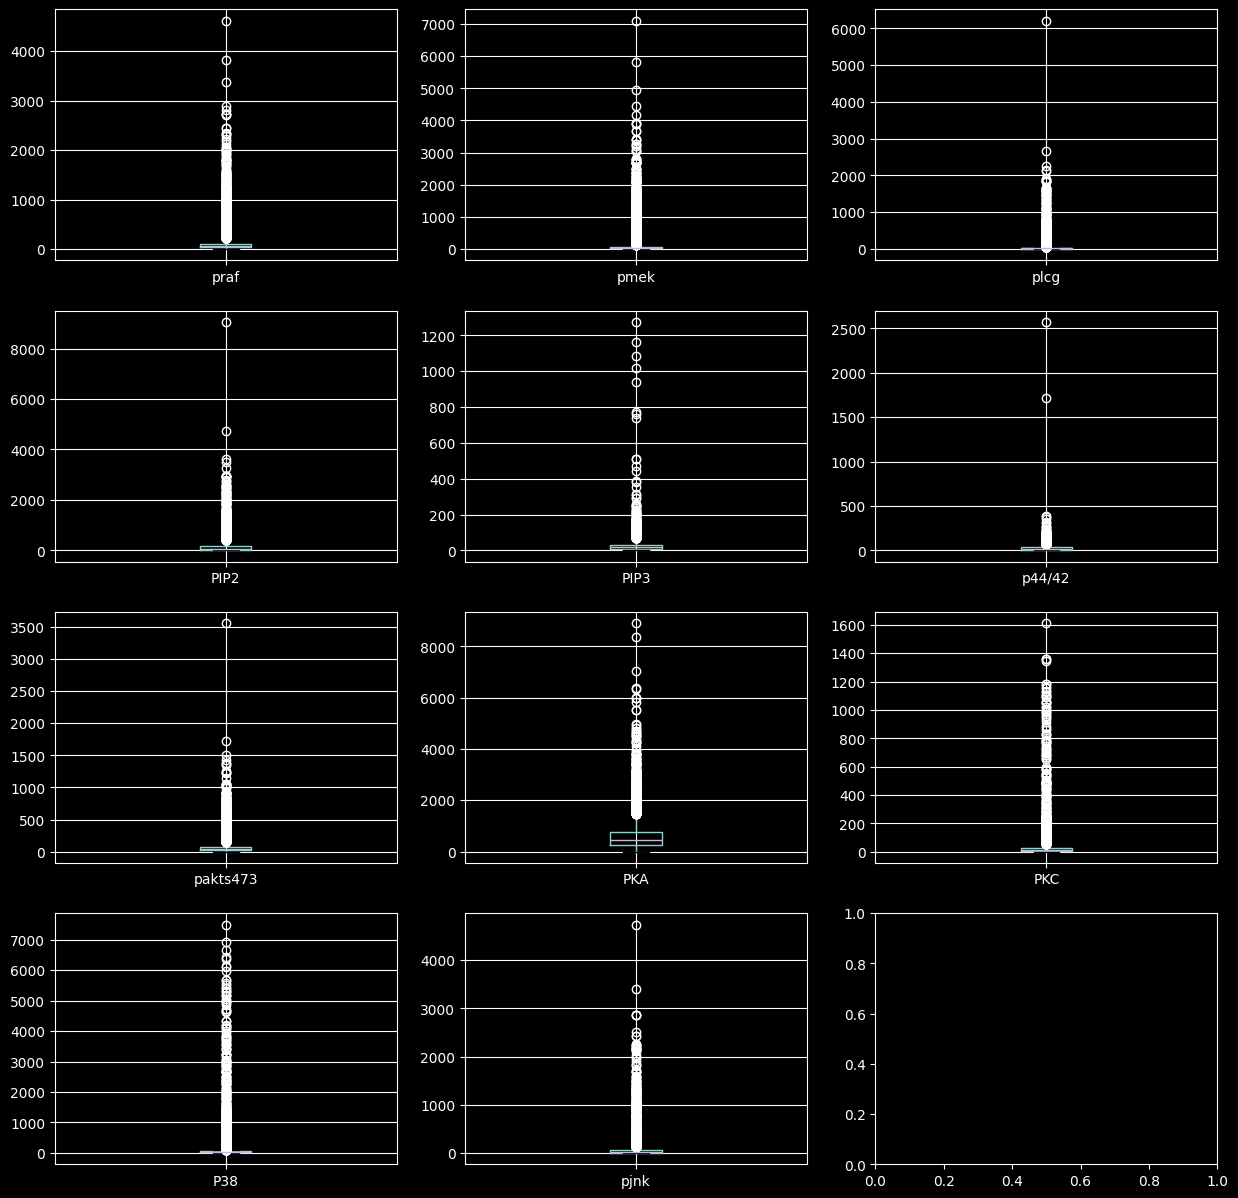

In [7]:
# Plot boxplots for each variable
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
for i, column in enumerate(sachs_df.columns):
    sachs_df.boxplot(column=column, ax=axes[i // 3, i % 3])
plt.show()

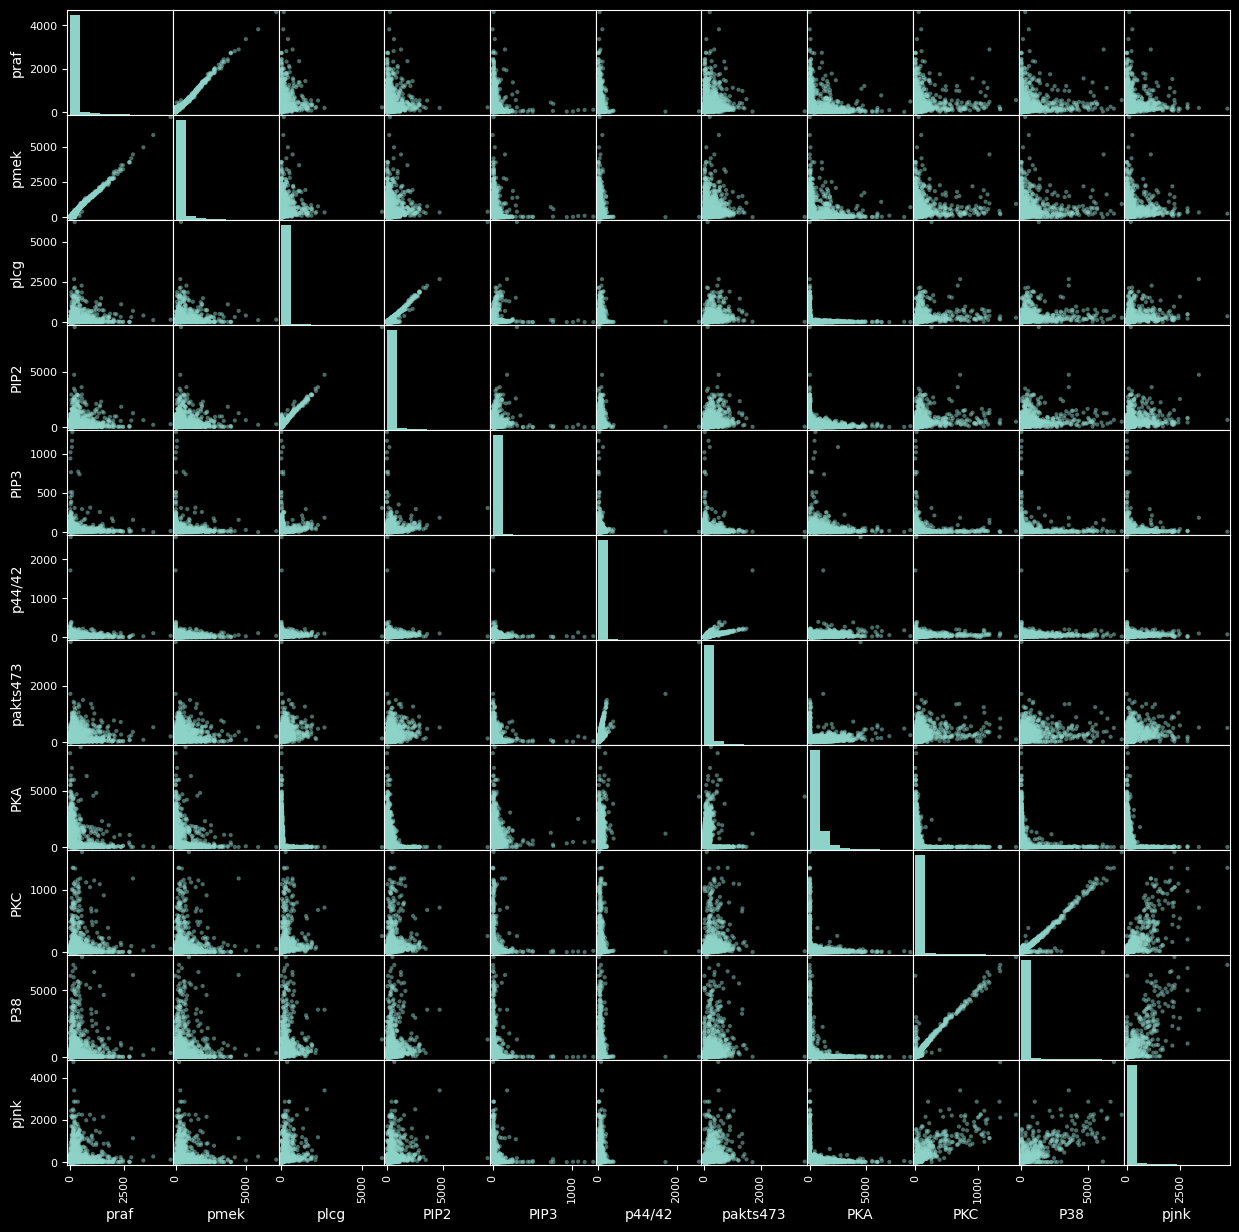

In [8]:
# Plot individual scatter plots between each pair of variables
pd.plotting.scatter_matrix(sachs_df, figsize=(15, 15), diagonal="hist")
plt.show()

<center>
  <a id="fig-scatter"></a>
  <h6>Figure 4.4: Scatter Plot</h6>
</center>

#### 4.4.3.2 True Causal Graph

[Figure 4.5](fig-sachtrue) shows the actual causal DAG model for comparison with algorithm-generated structures.

In [12]:
# create a text file
with open("sachs.txt", "w") as file:
    file.write(
        "Graph Nodes:\n praf;pmek;plcg;PIP2;PIP3;p44/42;pakts473;PKA;PKC;P38;pjnk \n Graph Edges: \n1. PIP2 --> PKC\n2. plcg --> PIP2\n3. PIP3 --> plcg\n4. PIP2 --> PIP3\n5. plcg --> PKC\n6. PKC --> pjnk\n7. PKC --> P38\n8. PKA --> P38\n9. PKC --> praf\n10. PKA --> praf\n11. praf --> pmek\n12. pmek --> p44/42\n13. PKC --> pmek\n14. PKA --> pakts473\n15. PIP3 --> pakts473\n16. PKA --> pmek\n17. PKA --> p44/42\n18. PKA --> pjnk\n"
    )

# print the contents of the text file
with open("sachs.txt", "r") as file:
    print(file.read())

Graph Nodes:
 praf;pmek;plcg;PIP2;PIP3;p44/42;pakts473;PKA;PKC;P38;pjnk 
 Graph Edges: 
1. PIP2 --> PKC
2. plcg --> PIP2
3. PIP3 --> plcg
4. PIP2 --> PIP3
5. plcg --> PKC
6. PKC --> pjnk
7. PKC --> P38
8. PKA --> P38
9. PKC --> praf
10. PKA --> praf
11. praf --> pmek
12. pmek --> p44/42
13. PKC --> pmek
14. PKA --> pakts473
15. PIP3 --> pakts473
16. PKA --> pmek
17. PKA --> p44/42
18. PKA --> pjnk



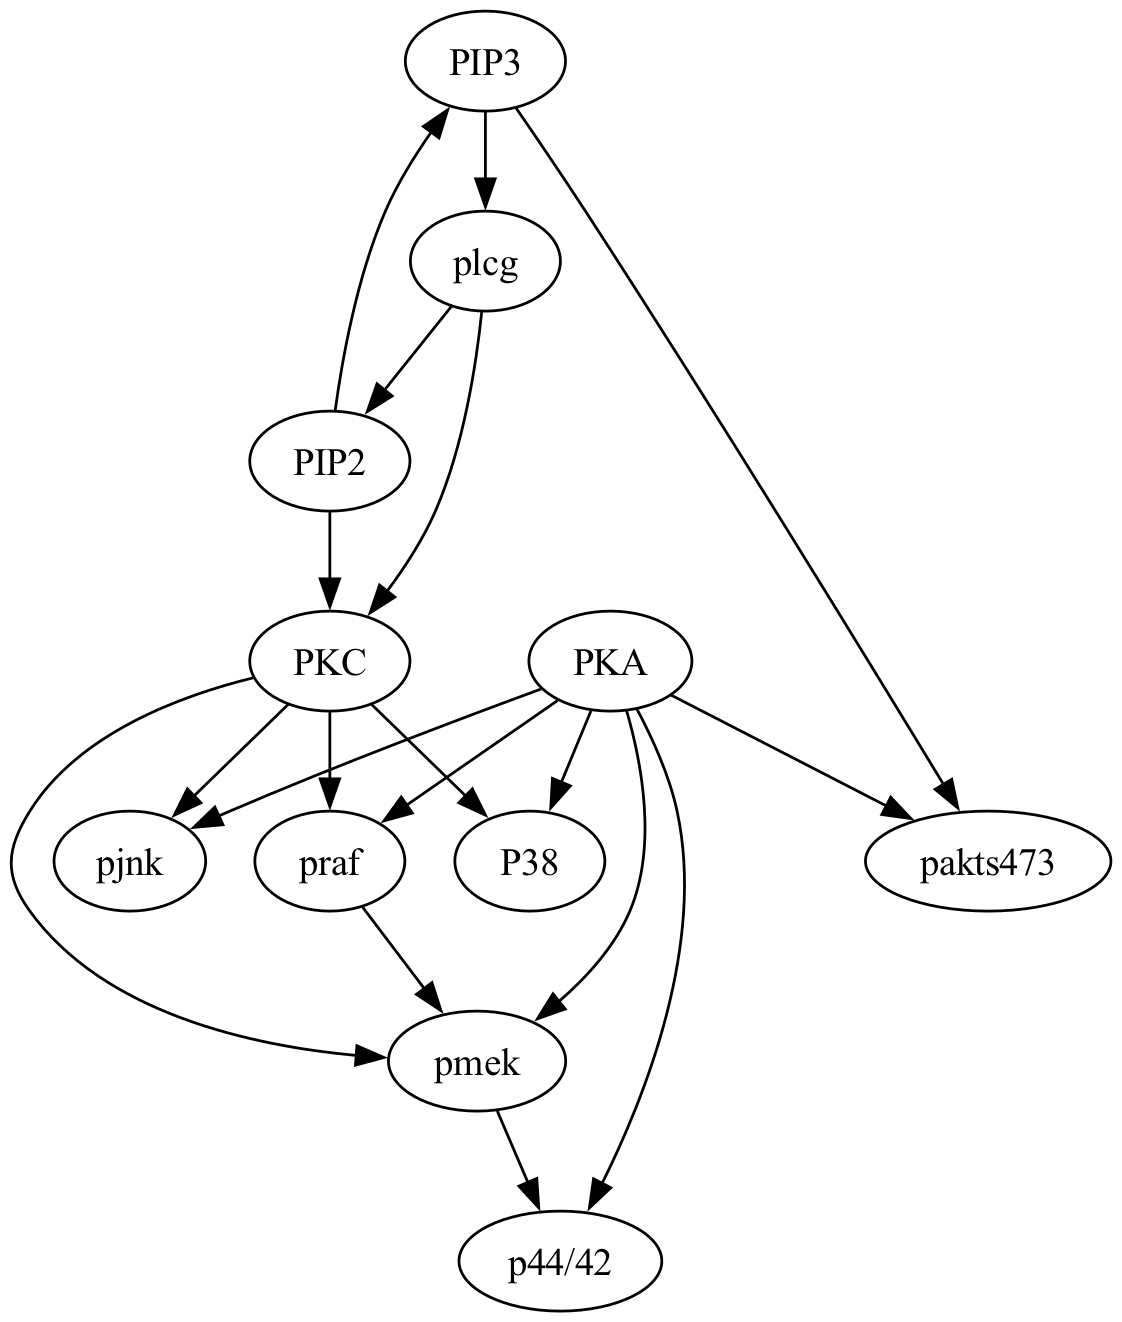

In [13]:
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.utils.TXT2GeneralGraph import txt2generalgraph
from IPython.display import Image, display

label_mapping = {
    "0": "praf",
    "1": "pmek",
    "2": "plcg",
    "3": "PIP2",
    "4": "PIP3",
    "5": "p44/42",
    "6": "pakts473",
    "7": "PKA",
    "8": "PKC",
    "9": "P38",
    "10": "pjnk",
}


def update_node_labels(graph, label_mapping):
    for node in graph.get_nodes():
        node_name = node.get_name()
        if node_name in label_mapping:
            node.set_label(label_mapping[node_name])


truth_sachs_dag = txt2generalgraph("sachs.txt")
# convert to pydot
graphviz_pag = GraphUtils.to_pydot(truth_sachs_dag)
# Explicitly set the path to the dot executable
graphviz_pag.set_prog("/opt/homebrew/bin/dot")
# change the node labels
update_node_labels(graphviz_pag, label_mapping)
# to png format
graphviz_pag.write_png("original_dag.png")
display(Image("original_dag.png"))


<center>
  <a id="fig-sachstrue"></a>
  <h6>Figure 4.5: True Causal Graph</h6>
</center>


#### 4.4.3.3 PC Algorithm

The causal-learn package offers simple default parameter usage. No parameter tuning is applied in this case study.

  0%|          | 0/11 [00:00<?, ?it/s]

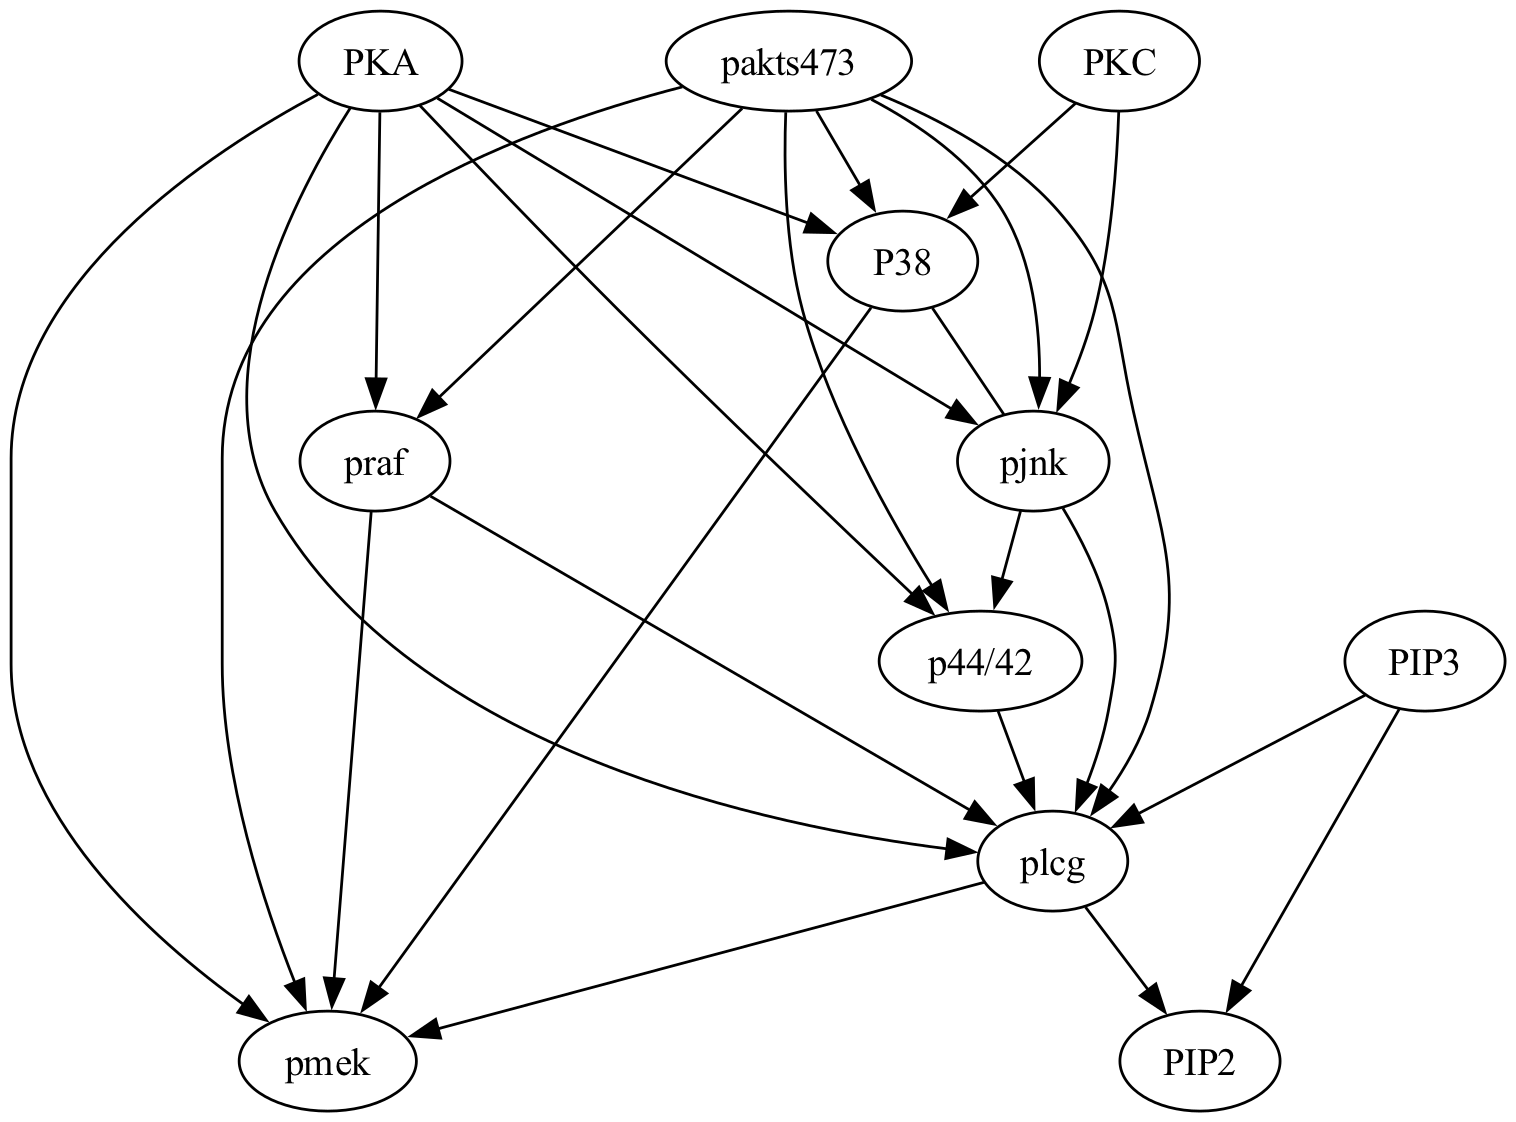

In [16]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image

# default parameters
cg = pc(data)
pd_pc_graph = GraphUtils.to_pydot(cg.G)
# Explicitly set the path to the dot executable
pd_pc_graph.set_prog("/opt/homebrew/bin/dot")
# change the node labels
update_node_labels(pd_pc_graph, label_mapping)
# visualization using pydot
img = Image(pd_pc_graph.create_png())
display(img)

<center>
  <img
    src="images/sachs_true_vs_pc.png"
    alt="True causal diagram (left) vs. the structure learned by the PC algorithm (right)"
    width="400"/>
    <a id="fig-trueandpc"></a>
  <h6>Figure 4.6: True causal diagram (left) vs. the structure learned by the PC algorithm (right)</h6>
</center>

Comparing the true causal graph with the PC algorithm's output ([Figure 4.6](#fig-trueandpc)) reveals key observations:

* Missing edges include $PKA \longrightarrow pAKT-S473$, $pMEK \longrightarrow p44/42$, and $PIP3 \longrightarrow pAKT-S473$.
* Edges point in wrong directions, e.g. $PIP3 \longrightarrow PIP2$.
* The PC algorithm adds incorrect edges, e.g. $plcg \longrightarrow pmek$.


#### 4.4.3.4 FCI Algorithm

  0%|          | 0/11 [00:00<?, ?it/s]

X3 --> X4
X7 --> X11


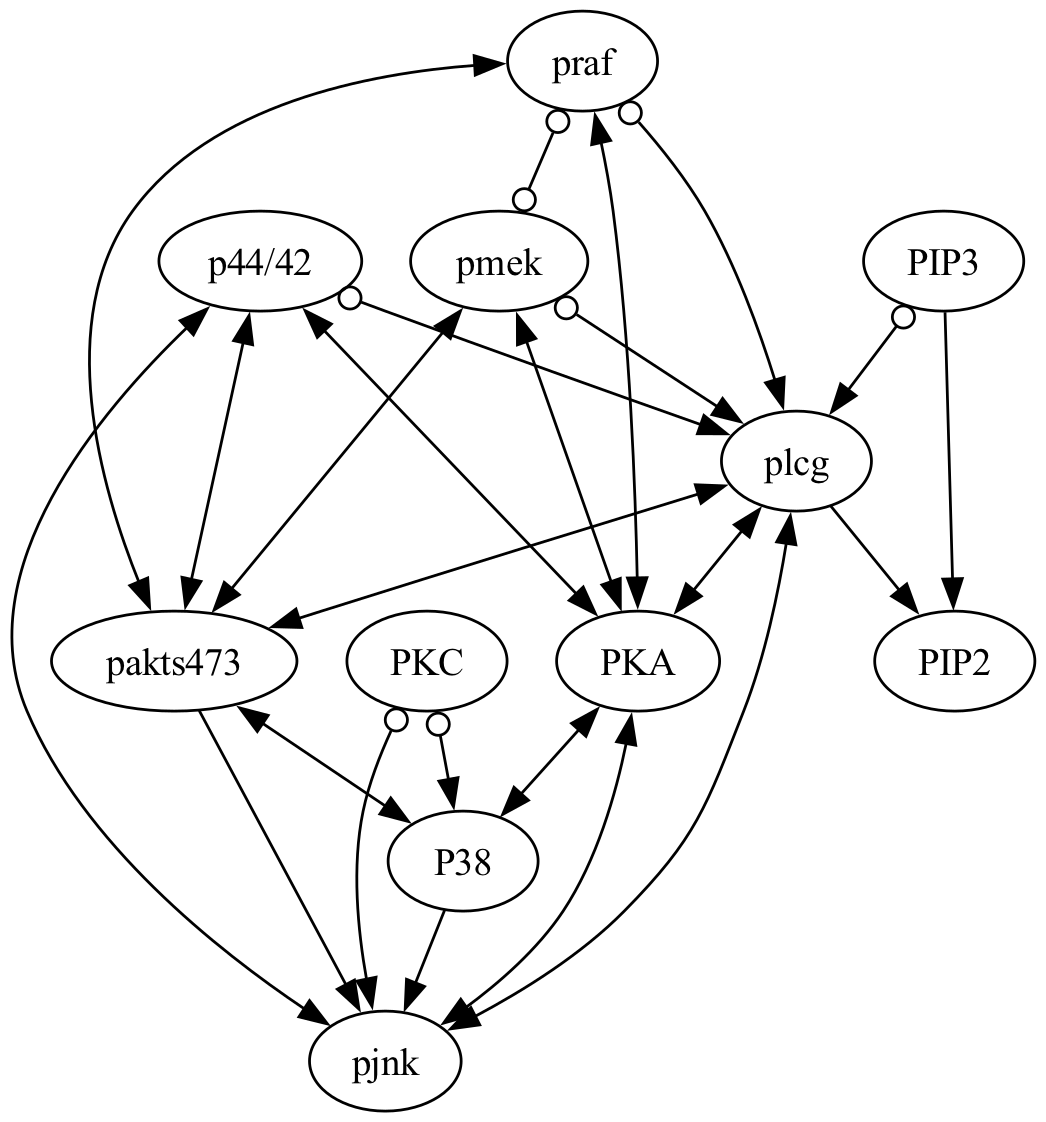

In [17]:
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.FCI import fci

# default parameters
G, edges = fci(data)

fci_graph = GraphUtils.to_pydot(G)
# Explicitly set the path to the dot executable
fci_graph.set_prog("/opt/homebrew/bin/dot")
# change the node labels
update_node_labels(fci_graph, label_mapping)
# visualization using pydot
img = Image(fci_graph.create_png())
display(img)


Comparing the true causal graph with the FCI-generated graph ([Figure 4.7](fig-trueandfci)) reveals notable differences.

* Missing edges include $PKA \longrightarrow pAKT-S473$, $pMEK \longrightarrow p44/42$, and $PIP3 \longrightarrow pAKT-S473$, similar to the PC algorithm.
* Wrong edge directions, e.g. $PIP3 \longrightarrow PIP2$.
* FCI has more erroneous edges than PC.
* The FCI algorithm introduces bidirectional edges where the PC algorithm had directed ones. For example, the $PKA \longrightarrow p44/42$ and $praf \longrightarrow pmek$ edges, correctly directed in PC, become bidirectional in FCI.

<center>
  <img
    src="images/sachs_true_vs_fci.png"
    alt="True causal diagram (left) vs. the structure learned by the FCI algorithm (right)"
    width="400"/>
  <a id="fig-trueandfci"></a>
  <h6>Figure 4.7: True causal diagram (left) vs. the structure learned by the FCI algorithm (right)</h6>
</center>


#### 4.4.3.5 GES Algorithm

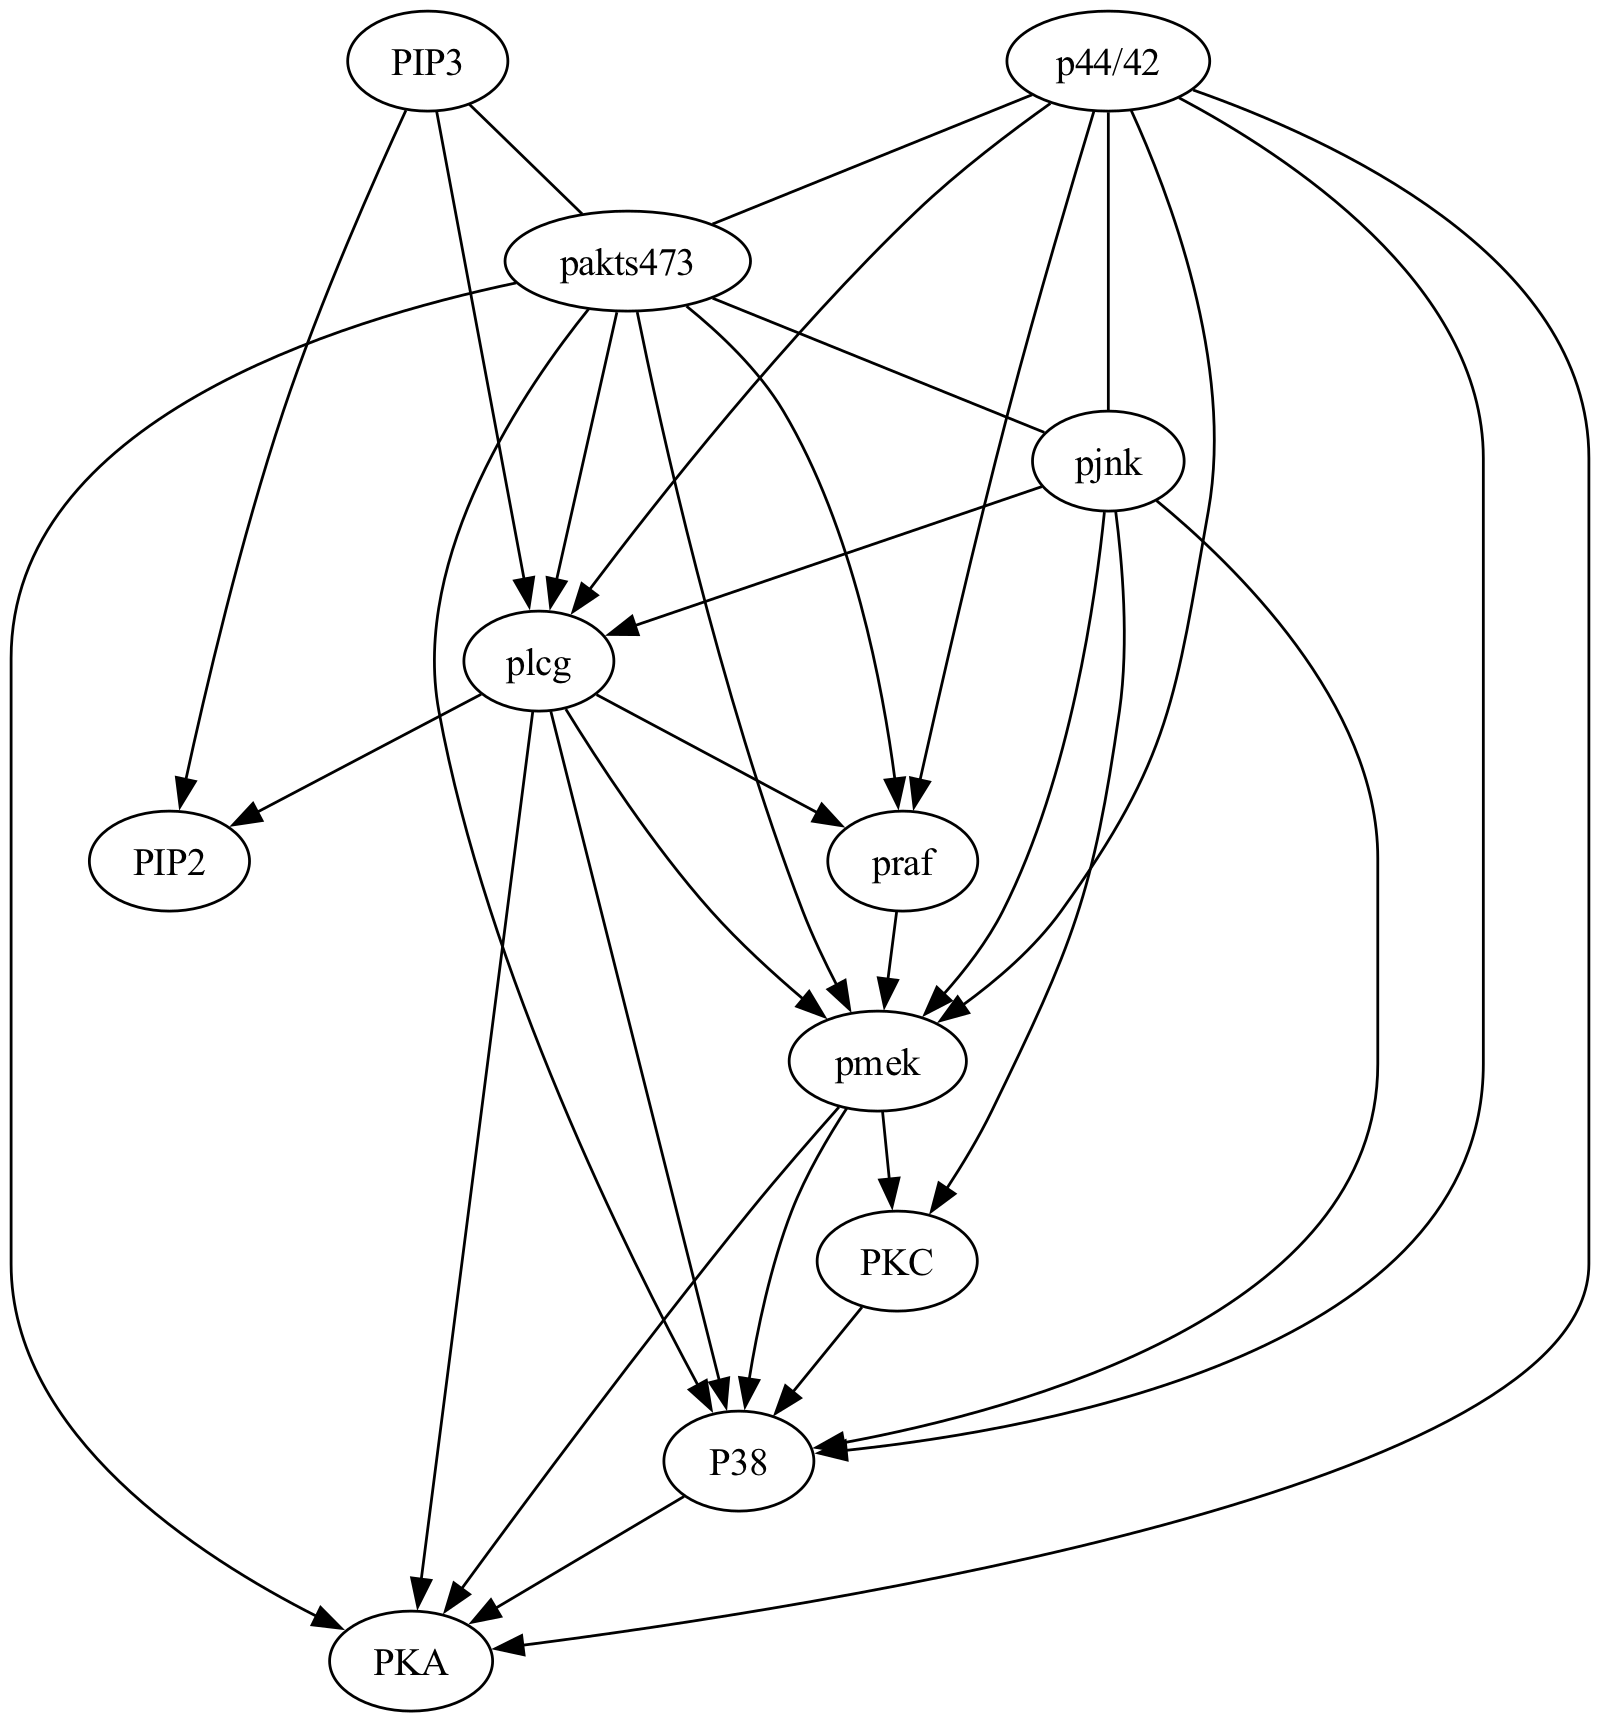

In [18]:
import matplotlib.pyplot as plt
from causallearn.search.ScoreBased.GES import ges

# default parameters
ges_default_graph = ges(data)

# Visualization using pydot
ges_graph = GraphUtils.to_pydot(ges_default_graph["G"])
# Explicitly set the path to the dot executable
ges_graph.set_prog("/opt/homebrew/bin/dot")
# change the node labels
update_node_labels(ges_graph, label_mapping)

# visualization using pydot
img = Image(ges_graph.create_png())
display(img)


Comparing the true causal graph with the GES-generated graph ([Figure 4.8](#fig-trueandges)) reveals notable differences.

* Missing edges: $PKA \longrightarrow pakts473$, $pmek \longrightarrow p44/42$. Discovered: $PIP3 \longrightarrow pakts473$.
* Edges like $PIP3 \longrightarrow PIP2$ show wrong directions, similar to PC and FCI.
* GES incorrectly identified some edges that PC and FCI correctly identified, e.g., $PKC \longrightarrow pjnk$.

<center>
  <img
    src="images/sachs_true_vs_ges.png"
    alt="True causal diagram (left) vs. the structure learned by the GES algorithm (right)"
    width="400"/>
  <a id="fig-trueandges"></a>
  <h6>Figure 4.8: True causal diagram (left) vs. the structure learned by the GES algorithm (right)</h6>
</center>

#### 4.4.3.6 LiNGAM Algorithm

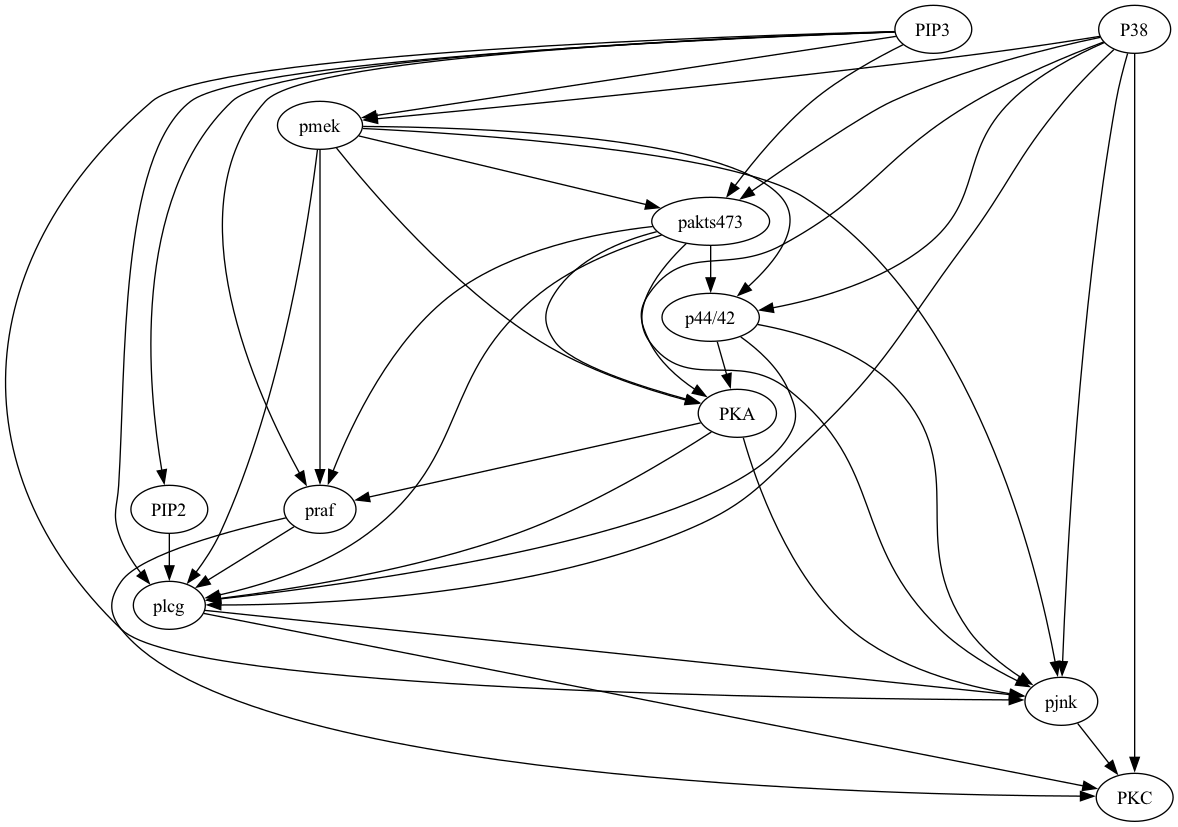

In [19]:
import matplotlib.pyplot as plt
import networkx as nx
from causallearn.search.FCMBased import lingam

model = lingam.DirectLiNGAM()
model.fit(data)

# create DAG using NetworkX
dag = nx.DiGraph(model.adjacency_matrix_)

pd_lingam_graph = nx.drawing.nx_pydot.to_pydot(dag)
# Explicitly set the path to the dot executable
pd_lingam_graph.set_prog("/opt/homebrew/bin/dot")
# update the node labels
update_node_labels(pd_lingam_graph, label_mapping)

# visualization using pydot
img = Image(pd_lingam_graph.create_png())
display(img)


Comparing the true causal graph with the LiNGAM-generated version ([Figure 4.9](fig-trueandlingam)) reveals key differences.

* Compared to PC and FCI, $pMEK \longrightarrow p44/42$ is the only missing pathway; $PKA \longrightarrow pAKT473$ and $PIP3 \longrightarrow pAKT473$ have been discovered.
* Edges show wrong directions like PC, FCI, and GES, e.g., $PIP3 \longrightarrow PIP2$.
* PC and FCI sometimes incorrectly direct edges like $PKC \longrightarrow JNK$, similar to GES.

<center>
  <img
    src="images/sachs_true_vs_lingam.png"
    alt="True causal diagram (left) vs. the structure learned by the LiNGAM algorithm (right)"
    width="400"/>
  <a id="fig-trueandlingam"></a>
  <h6>Figure 4.9: True causal diagram (left) vs. the structure learned by the LiNGAM algorithm (right)</h6>
</center>
